# Home Credit Default Risk Analysis
## Business Problem
> ### Can we predict whether an applicant will experience payment difficulties based on information available at the time of application? 

In [1]:
# Let's inspect the data
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('../data/raw/credit_default_data/application_train.csv')

In [4]:
df.shape

(307511, 122)

In [5]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), str(16)
memory usage: 286.2 MB


In [7]:
df.describe()

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,...,307511.000000,307511.000000,307511.000000,307511.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000,265992.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.573909,5.383962e+05,0.020868,-16036.995067,63815.045904,...,0.008130,0.000595,0.000507,0.000335,0.006402,0.007000,0.034362,0.267395,0.265474,1.899974
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737315,3.694465e+05,0.013831,4363.988632,141275.766519,...,0.089798,0.024387,0.022518,0.018299,0.083849,0.110757,0.204685,0.916002,0.794056,1.869295
min,100002.000000,0.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,0.000290,-25229.000000,-17912.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,189145.500000,0.000000,0.000000,1.125000e+05,2.700000e+05,16524.000000,2.385000e+05,0.010006,-19682.000000,-2760.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,278202.000000,0.000000,0.000000,1.471500e+05,5.135310e+05,24903.000000,4.500000e+05,0.018850,-15750.000000,-1213.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,367142.500000,0.000000,1.000000,2.025000e+05,8.086500e+05,34596.000000,6.795000e+05,0.028663,-12413.000000,-289.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
max,456255.000000,1.000000,19.000000,1.170000e+08,4.050000e+06,258025.500000,4.050000e+06,0.072508,-7489.000000,365243.000000,...,1.000000,1.000000,1.000000,1.000000,4.000000,9.000000,8.000000,27.000000,261.000000,25.000000


In [8]:
df['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [9]:
df["TARGET"].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [10]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


### Target VS Features
----------------------
#### Our machine learning formulation is
#### $X -> y$
#### Where X is the feature matrix (total_income, credit_amt, birth_date,...)
#### y is our target

In [11]:
# Let's inspect the columns systematically
df.columns.tolist()

['SK_ID_CURR',
 'TARGET',
 'NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'CNT_CHILDREN',
 'AMT_INCOME_TOTAL',
 'AMT_CREDIT',
 'AMT_ANNUITY',
 'AMT_GOODS_PRICE',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'REGION_POPULATION_RELATIVE',
 'DAYS_BIRTH',
 'DAYS_EMPLOYED',
 'DAYS_REGISTRATION',
 'DAYS_ID_PUBLISH',
 'OWN_CAR_AGE',
 'FLAG_MOBIL',
 'FLAG_EMP_PHONE',
 'FLAG_WORK_PHONE',
 'FLAG_CONT_MOBILE',
 'FLAG_PHONE',
 'FLAG_EMAIL',
 'OCCUPATION_TYPE',
 'CNT_FAM_MEMBERS',
 'REGION_RATING_CLIENT',
 'REGION_RATING_CLIENT_W_CITY',
 'WEEKDAY_APPR_PROCESS_START',
 'HOUR_APPR_PROCESS_START',
 'REG_REGION_NOT_LIVE_REGION',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'REG_CITY_NOT_LIVE_CITY',
 'REG_CITY_NOT_WORK_CITY',
 'LIVE_CITY_NOT_WORK_CITY',
 'ORGANIZATION_TYPE',
 'EXT_SOURCE_1',
 'EXT_SOURCE_2',
 'EXT_SOURCE_3',
 'APARTMENTS_AVG',
 'BASEMENTAREA_AVG',
 'YEARS_BEGINEXPLUATATION_A

In [12]:
# let's get the categorical columns
categorical_cols = df.select_dtypes(include="object").columns

categorical_cols.tolist()

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_90045/525559232.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


['NAME_CONTRACT_TYPE',
 'CODE_GENDER',
 'FLAG_OWN_CAR',
 'FLAG_OWN_REALTY',
 'NAME_TYPE_SUITE',
 'NAME_INCOME_TYPE',
 'NAME_EDUCATION_TYPE',
 'NAME_FAMILY_STATUS',
 'NAME_HOUSING_TYPE',
 'OCCUPATION_TYPE',
 'WEEKDAY_APPR_PROCESS_START',
 'ORGANIZATION_TYPE',
 'FONDKAPREMONT_MODE',
 'HOUSETYPE_MODE',
 'WALLSMATERIAL_MODE',
 'EMERGENCYSTATE_MODE']

In [13]:
len(categorical_cols)

16

In [14]:
numerical_cols = df.select_dtypes(
    include=["int64", "float64"]
).columns

len(numerical_cols)

106

In [20]:
# Now let's inspect the categorical variables
for col in categorical_cols:
    #print(f"\n{col}")
    print(df[col].value_counts(dropna=False).head(10))

NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64
FLAG_OWN_REALTY
Y    213312
N     94199
Name: count, dtype: int64
NAME_TYPE_SUITE
Unaccompanied      248526
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
NaN                  1292
Other_A               866
Group of people       271
Name: count, dtype: int64
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower seconda

In [24]:
df.isna().sum()

SK_ID_CURR                        0
TARGET                            0
NAME_CONTRACT_TYPE                0
CODE_GENDER                       0
FLAG_OWN_CAR                      0
                              ...  
AMT_REQ_CREDIT_BUREAU_DAY     41519
AMT_REQ_CREDIT_BUREAU_WEEK    41519
AMT_REQ_CREDIT_BUREAU_MON     41519
AMT_REQ_CREDIT_BUREAU_QRT     41519
AMT_REQ_CREDIT_BUREAU_YEAR    41519
Length: 122, dtype: int64

In [26]:
# let's quantify missing data
missing  = (df.isna().sum().to_frame("missing_count"))
missing

,missing_count
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,41519
AMT_REQ_CREDIT_BUREAU_WEEK,41519
AMT_REQ_CREDIT_BUREAU_MON,41519
AMT_REQ_CREDIT_BUREAU_QRT,41519


In [27]:
missing["missing_percent"] = (
    missing["missing_count"] / len(df) * 100
)

In [28]:
missing = (
    missing[missing["missing_count"] > 0]
    .sort_values("missing_percent", ascending=False)
)

In [29]:
missing.head(20)

,missing_count,missing_percent
COMMONAREA_MEDI,214865,69.872297
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_MODE,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_AVG,210199,68.354953


In [30]:
# duplicate applications
df["SK_ID_CURR"].duplicated().sum()

np.int64(0)

In [31]:
# complete duplicate rows
df.duplicated().sum()

np.int64(0)

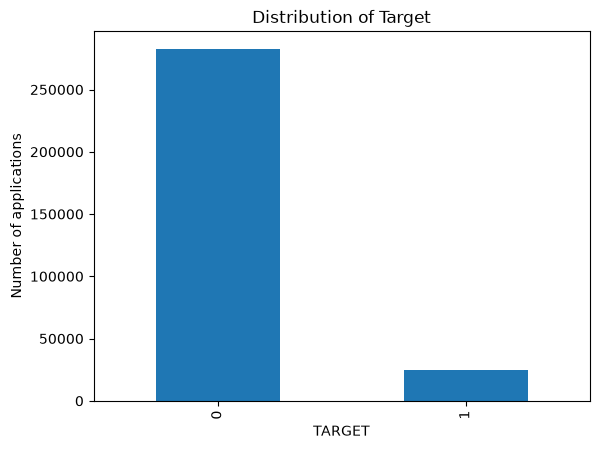

In [32]:
# Let's visualize the target
import matplotlib.pyplot as plt

df["TARGET"].value_counts().plot(kind="bar")

plt.xlabel("TARGET")
plt.ylabel("Number of applications")
plt.title("Distribution of Target")
plt.show()

In [33]:
# Let's see the missing data more clearly
missing["missing_percent"].describe()

count    67.000000
mean     44.422461
std      24.092191
min       0.000325
25%      25.585426
50%      50.749729
75%      62.683774
max      69.872297
Name: missing_percent, dtype: float64

In [ ]:
# how many columns have more than 50% missing values
missing[missing["missing_percent"] > 50].shape

(41, 2)

In [35]:
missing[missing["missing_percent"] > 30].shape

(50, 2)

In [36]:
missing[missing["missing_percent"] == 0].shape

(0, 2)

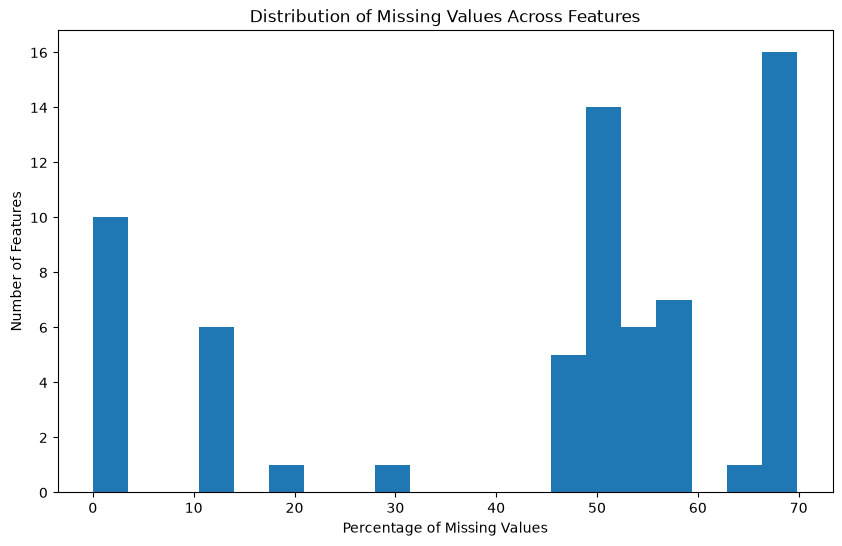

In [37]:
# let's see complete missing distribution
plt.figure(figsize=(10, 6))

plt.hist(
    missing["missing_percent"],
    bins=20
)

plt.xlabel("Percentage of Missing Values")
plt.ylabel("Number of Features")
plt.title("Distribution of Missing Values Across Features")

plt.show()

In [38]:
# let's investigate the target relationship
# we don't just want to know the amount of missing values
# We want to know if missingness itself relate to the target
# let's take the example of OWN_CAR_AGE, it has around 66% missing values
# let's create a missingness indicator
df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype(int)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_90045/259141242.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["OWN_CAR_AGE_MISSING"] = df["OWN_CAR_AGE"].isna().astype(int)


In [43]:
df.groupby("TARGET")['OWN_CAR_AGE_MISSING'].mean()

TARGET
0    0.656842
1    0.694824
Name: OWN_CAR_AGE_MISSING, dtype: float64

In [39]:
df.groupby("OWN_CAR_AGE_MISSING")["TARGET"].mean()

OWN_CAR_AGE_MISSING
0    0.072441
1    0.085000
Name: TARGET, dtype: float64

In [44]:
# Let's investigate DAYS_EMPLOYED
df["DAYS_EMPLOYED"].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

In [45]:
df["DAYS_EMPLOYED"].value_counts().head(10)

DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-199         151
-230         151
-212         150
-229         143
-384         143
-231         140
-215         138
Name: count, dtype: int64

In [46]:
# We want to know how many records have the value 365243
(df["DAYS_EMPLOYED"] == 365243).sum()

np.int64(55374)

In [47]:
df.groupby(
    df["DAYS_EMPLOYED"] == 365243
)["TARGET"].mean()

DAYS_EMPLOYED
False    0.086600
True     0.053996
Name: TARGET, dtype: float64

In [48]:
# target rate by categorical variables
df.groupby("NAME_CONTRACT_TYPE")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
NAME_CONTRACT_TYPE,,
Cash loans,278232,0.083459
Revolving loans,29279,0.054783


In [49]:
df.groupby("CODE_GENDER")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
CODE_GENDER,,
F,202448,0.069993
M,105059,0.101419
XNA,4,0.000000


In [50]:
df.groupby("FLAG_OWN_CAR")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
FLAG_OWN_CAR,,
N,202924,0.085002
Y,104587,0.072437


In [51]:
df.groupby("FLAG_OWN_REALTY")["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
FLAG_OWN_REALTY,,
N,94199,0.083249
Y,213312,0.079616


#### Because Target is binary
#### $Mean(TARGET) = P(TARGET = 1)$

In [52]:
for col in [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)["TARGET"]
          .agg(["count", "mean"])
    )


--- NAME_CONTRACT_TYPE ---
                     count      mean
NAME_CONTRACT_TYPE                  
Cash loans          278232  0.083459
Revolving loans      29279  0.054783

--- CODE_GENDER ---
              count      mean
CODE_GENDER                  
F            202448  0.069993
M            105059  0.101419
XNA               4  0.000000

--- FLAG_OWN_CAR ---
               count      mean
FLAG_OWN_CAR                  
N             202924  0.085002
Y             104587  0.072437

--- FLAG_OWN_REALTY ---
                  count      mean
FLAG_OWN_REALTY                  
N                 94199  0.083249
Y                213312  0.079616


In [53]:
# Let's understand the target from the perspective of numerical features
important_numeric = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

In [56]:
# let's see the distribution
df[important_numeric].describe().T

,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307499.0,27108.573909,14493.737315,1615.5,16524.0,24903.0,34596.0,258025.5
AMT_GOODS_PRICE,307233.0,538396.207429,369446.460540,40500.0,238500.0,450000.0,679500.0,4050000.0
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-25229.0,-19682.0,-15750.0,-12413.0,-7489.0
DAYS_EMPLOYED,307511.0,63815.045904,141275.766519,-17912.0,-2760.0,-1213.0,-289.0,365243.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
CNT_FAM_MEMBERS,307509.0,2.152665,0.910682,1.0,2.0,2.0,3.0,20.0


In [61]:
# Let's see the classification problem
# Does income differ between target=0 and target=1
df.groupby("TARGET")[important_numeric].median().T

TARGET,0,1
AMT_INCOME_TOTAL,148500.0,135000.0
AMT_CREDIT,517788.0,497520.0
AMT_ANNUITY,24876.0,25263.0
AMT_GOODS_PRICE,450000.0,450000.0
DAYS_BIRTH,-15877.0,-14282.0
DAYS_EMPLOYED,-1235.0,-1034.0
CNT_CHILDREN,0.0,0.0
CNT_FAM_MEMBERS,2.0,2.0


In [ ]:
# Why median because we have seen enormous outliers, median is more robust


In [58]:
# Let's examine target rate across groups
# creating income quantile group
df["income_group"] = pd.qcut(
    df["AMT_INCOME_TOTAL"],
    q=10,
    duplicates="drop"
)

/var/folders/rr/0n4wysh90tn8pghdwg390f580000gn/T/ipykernel_90045/2700594221.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["income_group"] = pd.qcut(


In [59]:
df.groupby("income_group", observed=True)["TARGET"].agg(
    ["count", "mean"]
)

,count,mean
income_group,,
"(25649.999, 81000.0]",33391,0.081908
"(81000.0, 99000.0]",30280,0.082232
"(99000.0, 112500.0]",36907,0.087192
"(112500.0, 135000.0]",48849,0.084894
"(135000.0, 147150.0]",4333,0.090007
"(147150.0, 162000.0]",31120,0.086407
"(162000.0, 180000.0]",30704,0.084224
"(180000.0, 225000.0]",44809,0.078065
"(225000.0, 270000.0]",19957,0.070401


In [62]:
# Before doing all the manipulation, let's build the first baseline model
# first let's quantify what exactly naive majority class model would achieve 
baseline_accuracy = (df['TARGET'] == 0).mean()
baseline_accuracy

np.float64(0.9192711805431351)

In [63]:
baseline_recall = 0

baseline_accuracy, baseline_recall

(np.float64(0.9192711805431351), 0)

In [64]:
baseline_accuracy = (df["TARGET"] == 0).mean()

print(f"Baseline accuracy: {baseline_accuracy:.4f}")

Baseline accuracy: 0.9193


In [65]:
X = df[['AMT_INCOME_TOTAL',
'AMT_CREDIT',
'AMT_ANNUITY',
'AMT_GOODS_PRICE',
'DAYS_BIRTH',
'DAYS_EMPLOYED',
'CNT_CHILDREN',
'CNT_FAM_MEMBERS',
'NAME_CONTRACT_TYPE',
'CODE_GENDER',
'FLAG_OWN_CAR',
'FLAG_OWN_REALTY']]

Y = df['TARGET']

In [73]:
# Train and Test split
# Stratification: It tells the splitter to preserve the same distribution in both datasets
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    Y,
    test_size=0.20,
    stratify=Y,
    random_state=42
)

In [69]:
X.shape

(307511, 12)

In [70]:
Y.shape

(307511,)

In [75]:
print("X_train:", X_train.shape)
print("X_val :", X_val.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nVal target distribution:")
print(y_val.value_counts(normalize=True))

X_train: (246008, 12)
X_val : (61503, 12)

Training target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

Val target distribution:
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [76]:
# Let's try to fit the logistic regression directly
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Cash loans'

                         X
                         │
             ┌───────────┴───────────┐
             │                       │
        Numerical                Categorical
        Features                  Features
             │                       │
             ▼                       ▼
       Imputation                 Imputation
             │                       │
             ▼                       ▼
          Scaling                 Encoding
             │                       │
             └───────────┬───────────┘
                         │
                         ▼
                Logistic Regression
                         │
                         ▼
                    Probability
                         │
                         ▼
                     Class

### Pipeline
#### Let's create our pipeline and keep improving the model

### Step-1: Preprocessing
#### We currently have
>#### X_train, y_train
>#### X_val, y_val
>#### 12 selected features
>#### ~246k training observations
>#### ~61.5k validation observations
>#### Positive class (TARGET=1) ≈ 8.07%

In [ ]:
# Problem - 1: Missing values
# Problem - 2: Categorical Value
# Problem - 3: Different Numerical Scale 

In [77]:
# Separate numerical and categorical features
numeric_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

categorical_features = [
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY"
]

In [80]:
# Numerical preprocessing
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [81]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [82]:
# Categorical preprocessing
from sklearn.preprocessing import OneHotEncoder

In [90]:
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

In [91]:
# Combine both transformation
from sklearn.compose import ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

In [92]:
# Let's create the first logistic regression model
from sklearn.linear_model import LogisticRegression

In [93]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [94]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['AMT_INCOME_TOTAL','AMT_CREDIT','AMT_ANNUITY',...,'CODE_GENDER', 'FLAG_OWN_CAR','FLAG_OWN_REALTY']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying 

In [95]:
X_train_transformed = model.named_steps["preprocessor"].transform(X_train)

X_train_transformed.shape

(246008, 13)

In [96]:
X_train.shape

(246008, 12)

In [97]:
# Let's do the probability prediction
y_val_proba = model.predict_proba(X_val)

y_val_proba.shape

(61503, 2)

In [98]:
y_val_proba[:10]

array([[0.90995136, 0.09004864],
       [0.92673955, 0.07326045],
       [0.91614047, 0.08385953],
       [0.897421  , 0.102579  ],
       [0.92246521, 0.07753479],
       [0.89169634, 0.10830366],
       [0.96182298, 0.03817702],
       [0.96942325, 0.03057675],
       [0.90345457, 0.09654543],
       [0.95952492, 0.04047508]])

In [ ]:
# Probability is not same as prediction
# suppose model says probability of default = 0.09
# We need a threshold to classify


In [99]:
# Let's see what model actually predicts
y_val_pred = model.predict(X_val)

y_val_pred[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [100]:
y_val_proba[:20, 1]

array([0.09004864, 0.07326045, 0.08385953, 0.102579  , 0.07753479,
       0.10830366, 0.03817702, 0.03057675, 0.09654543, 0.04047508,
       0.0647834 , 0.09853685, 0.13036187, 0.1033554 , 0.11875107,
       0.06025021, 0.05688712, 0.05246278, 0.08275595, 0.06885176])

In [102]:
# Let's quantify what our model is actually doing
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_val, y_val_pred)

cm

array([[56538,     0],
       [ 4965,     0]])